# Descriptive and Inference Statistics

I will use descriptive statistics to summarize -
- Distribution and range of data
- Central Limit Theorem & sampling
- Bootstraping - Apply the ‘Plug-in principle’ to complement CLT inferences
- Confidence intervals
- Hypothesis testing
- Chi-squared tests for independence and categorical relationships
- Analysis Of Variance (ANOVA) for multi-group comparison - check if there are statistcal difference between means of three or more groups.
- Visualization for interpretation

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from stats_utils import (
    descriptive_statistics,
    confidence_interval_mean,
    perform_ttest,
    perform_anova,
    perform_chi2_test,
    central_limit_theorem_sampling,
    bootstrap_confidence_interval,
    calculate_z_score
)
df = pd.read_csv('../data/raw/telco-customer-churn-ibm.csv')
# Example
z = calculate_z_score(80, mean=70, std=5)
print(f"Z-score of 80: {z}")

# Or for whole column
df['MonthlyCharges_z'] = calculate_z_score(df['MonthlyCharges'])

Z-score of 80: 2.0


## Descriptive Statistics for MonthlyCharges

In [5]:
desc_stats = descriptive_statistics(df['MonthlyCharges'])
print("Descriptive Statistics for MonthlyCharges:")
for k, v in desc_stats.items():
    print(f"{k.capitalize()}: {v:.2f}")

Descriptive Statistics for MonthlyCharges:
Mean: 64.76
Median: 70.35
Mode: 20.05
Std: 30.09
Variance: 905.41


# Confidence Interval for mean
## 95% Confidence Interval for Average MonthlyCharges

In [6]:
ci = confidence_interval_mean(df['MonthlyCharges'])
print(f"95% Confidence interval for mean MonthlyCharges: {ci[0]:.2f} to {ci[1]:.2f}")

95% Confidence interval for mean MonthlyCharges: 64.06 to 65.46


# Visualize CLT sampling distribution
## Central Limit Theorem: Sampling Distribution of the Mean

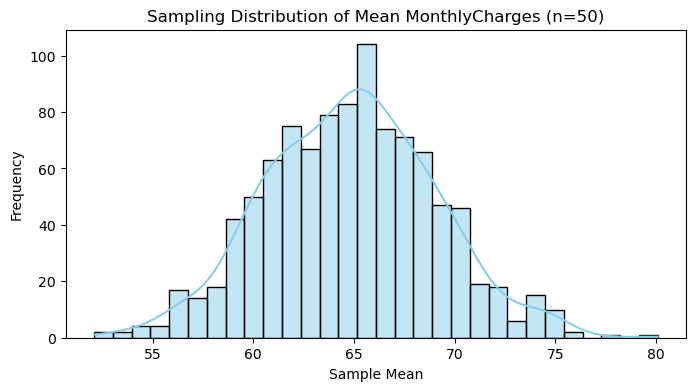

In [5]:
sample_means = central_limit_theorem_sampling(df['MonthlyCharges'], sample_size=50, n_samples=1000)

plt.figure(figsize=(8, 4))
sns.histplot(sample_means, kde=True, bins=30, color='skyblue')
plt.title('Sampling Distribution of Mean MonthlyCharges (n=50)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()

# Bootstrap Confidence Interval
## Bootstrap Confidence Interval for Mean MonthlyCharges

In [11]:
boot_ci = bootstrap_confidence_interval(df['MonthlyCharges'], n_bootstrap=1000, confidence=0.95)
print(f"Bootstrap 95% CI: {boot_ci[0]:.2f} to {boot_ci[1]:.2f}")

Bootstrap 95% CI: 64.07 to 65.49


In [6]:
df['MonthlyCharges_z'] = calculate_z_score(df['MonthlyCharges'])
print(df[['MonthlyCharges', 'MonthlyCharges_z']].head())

   MonthlyCharges  MonthlyCharges_z
0           29.85         -1.160241
1           56.95         -0.259611
2           53.85         -0.362635
3           42.30         -0.746482
4           70.70          0.197351


## Hypothesis Test: Do churned and non-churned customers have different MonthlyCharges?

In [7]:
churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned = df[df['Churn'] == 'No']['MonthlyCharges']

t_stat, p_val = perform_ttest(churned, not_churned)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Result: Statistically significant difference in MonthlyCharges between churned and non-churned customers.")
else:
    print("Result: No significant difference found.")


T-statistic: 18.41, p-value: 0.0000
Result: Statistically significant difference in MonthlyCharges between churned and non-churned customers.


## Chi-squared Test: Is Churn independent of Contract Type?

In [7]:
contingency = pd.crosstab(df['Churn'], df['Contract'])
chi2, p, dof, expected = perform_chi2_test(contingency)

print(f"Chi2 Statistic: {chi2:.2f}, p-value: {p:.4f}, dof: {dof}")
if p < 0.05:
    print("Result: Churn and Contract type are dependent.")
else:
    print("Result: No significant dependency between Churn and Contract type.")


Chi2 Statistic: 1184.60, p-value: 0.0000, dof: 2
Result: Churn and Contract type are dependent.


## ANOVA: Compare MonthlyCharges across Multiple Contract Types

In [8]:
group_monthly = [group['MonthlyCharges'] for _, group in df.groupby('Contract')]
f_stat, p_val = perform_anova(*group_monthly)
print(f"F-statistic: {f_stat:.2f}, p-value: {p_val:.4f}")
if p_val < 0.05:
    print("Result: Significant difference in MonthlyCharges across contract types.")
else:
    print("Result: No significant difference.")


F-statistic: 20.83, p-value: 0.0000
Result: Significant difference in MonthlyCharges across contract types.
